### Before choosing Jupyter Kernel run this in terminal:

```bash
python -m ipykernel install --user --name=venv --display-name "python3 for Jupyter (venv)"
```
After this:
1. Select Kernel
2. Jupyter Kernel
3. If you do not see the right one, use the refresh button in the top right corner
4. Choose `python3 for Jupyter (venv)` because it is matching the current project venv with all the required dependencies.

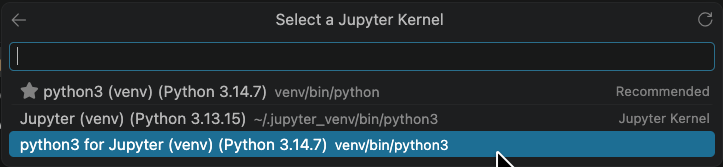

### Once cell for all imports and settings

This is the universal code snippet to be the top cell in this project's notebooks. Scroll to the next chapter to see a detailed breakdown for isolated functional blocks and usage examples.

In [2]:
# imports
import numpy as np
import pandas as pd
import warnings
import logging
import sys, os

# submodule imports
sys.path.append(os.path.abspath("libs/data_ravers_utils"))
import data_ravers_utils.file_handler as file_handler
import data_ravers_utils.eda_utils as auto_eda



# settings
pd.set_option('display.max_columns', None) # display all columns
warnings.filterwarnings('ignore')
logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.DEBUG, force=True)



### Detailed breakdown and usage examples

In [1]:
# import the most basic data analysis libs
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None) # display all columns

In [2]:
# ignore warnings for Jupyter notebooks
import warnings
warnings.filterwarnings('ignore')

In [3]:
# enable logging
import logging
logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.DEBUG, force=True)

In [10]:
# logging examples
logging.debug(f"Any debug information. For instance, this logger's name is: {logger.name}")
logging.info("Extra information on what's happening.")
logging.warning("This won't stop your code from running but you're doing something slightly off.")

try:
    this_fails = 1 / 0
except Exception as e:
    logging.error(f"Failed to do something. Error details: {e}")

DEBUG:root:Any debug information. For instance, this logger's name is: __main__
INFO:root:Extra information on what's happening.
ERROR:root:Failed to do something. Error details: division by zero


In [22]:
# set path to local modules and submodules
import sys, os
sys.path.append(os.path.abspath("libs/data_ravers_utils"))
# import local modules and submodules
import data_ravers_utils.file_handler as file_handler
import data_ravers_utils.eda_utils as auto_eda

#### data_ravers_utils.file_handler usage examples

In [4]:
# Generate a small sample dataframe for demoing library methods on.

# pandas has no dedicated "make fake data" function, so we lean on its own
# constructors (pd.DataFrame, pd.NA, pd.get_dummies) to build something messy
# on purpose: numeric + categorical columns, NaN/None/pd.NA nulls, whitespace-
# only strings, and duplicate rows.

data = {
    "id": [1, 2, 3, 4, 5, 6, 6],  # duplicate id (row 6 == row 7)
    "age": [25, np.nan, 31, 42, 25, np.nan, np.nan],  # numeric, with NaN
    "score": [8.5, 7.2, np.nan, 9.1, 8.5, 6.0, 6.0],  # numeric, with NaN
    "city": ["Berlin", "Paris", None, "Berlin", "Berlin", " ", " "],  # categorical, None + whitespace
    "grade": pd.array(["A", "B", "C", pd.NA, "A", "B", "B"], dtype="string"),  # categorical, pd.NA
}

df_1 = pd.DataFrame(data)
df_1


,id,age,score,city,grade
0,1,25.0,8.5,Berlin,A
1,2,NaN,7.2,Paris,B
2,3,31.0,NaN,NaN,C
3,4,42.0,9.1,Berlin,<NA>
4,5,25.0,8.5,Berlin,A
5,6,NaN,6.0,,B
6,6,NaN,6.0,,B


In [5]:
# set dataset filename baseline,
# no extension and filepath required!
df_filename = "sample_data" 

# export df to csv
# do not use for data backups! only for exports!!!
file_handler.save_df_as_csv(df_1, df_filename)

# read df from cs in a standard way
df_2 = pd.read_csv(f"./data/{df_filename}.csv")
print(f"\nData frame from CSV:\n{df_2.head(3)}")

# at the end of each notebook and before closing project
# backup data frame as pickle file to save space
file_handler.save_df_pickle(df_2, df_filename)

# restore dataframe from pickle file in the next notebook
df_3 = file_handler.read_df_pickle(df_filename)
print(f"\nData frame from pickle:\n{df_3.head(3)}")


INFO:root:CSV file created: /Users/bubblegum_doubledrops/0_repos/my_oss/data_science_project_template_by_faen/data/sample_data.csv
INFO:root:Backup file is created: /Users/bubblegum_doubledrops/0_repos/my_oss/data_science_project_template_by_faen/data/sample_data.pkl



Data frame from CSV:
   id   age  score    city grade
0   1  25.0    8.5  Berlin     A
1   2   NaN    7.2   Paris     B
2   3  31.0    NaN     NaN     C

Data frame from pickle:
   id   age  score    city grade
0   1  25.0    8.5  Berlin     A
1   2   NaN    7.2   Paris     B
2   3  31.0    NaN     NaN     C


#### data_ravers_utils.eda_utils usage examples

In [6]:
df = df_3.copy()
df


,id,age,score,city,grade
0,1,25.0,8.5,Berlin,A
1,2,NaN,7.2,Paris,B
2,3,31.0,NaN,NaN,C
3,4,42.0,9.1,Berlin,NaN
4,5,25.0,8.5,Berlin,A
5,6,NaN,6.0,,B
6,6,NaN,6.0,,B


In [27]:
# auto cleanup
auto_eda.auto_cleanup(df)

INFO:root:Number of rows before cleanup: 7
INFO:root:Dataset had empty spaces in some columns. They are replaced with NaN.
INFO:root:Dataset had duplicates. They had been dropped and index was reset.
INFO:root:Number of rows after cleanup: 6


In [28]:
# see nulls
df_nulls = auto_eda.count_nulls(df)
print(df_nulls)


       is_na  not_na  na_percent na_percent_pretty
age        2       4   33.333333            33.33%
city       2       4   33.333333            33.33%
score      1       5   16.666667            16.67%
grade      1       5   16.666667            16.67%
id         0       6    0.000000             0.00%


In [11]:
# quick EDA report
# generate report and capture cell output

from IPython.utils.capture import capture_output

# this code will be captured in memory and not displayed
with capture_output() as output:
    auto_eda.print_eda_report(df)

In [12]:
# quick EDA report
# display the report

print(output.stdout)

================= Dataset =================
Dataset has shape (7, 5)

Dataset has numerical data in columns: ['id', 'age', 'score']
- Column "id" has 6 unique values.
  -- Unique values are:
 [1 2 3 4 5 6]
- Column "score" has 4 unique values.
  -- Unique values are:
 [8.5 7.2 nan 9.1 6. ]
- Column "age" has 3 unique values.
  -- Unique values are:
 [25. nan 31. 42.]

Dataset has categorical data in columns: ['city', 'grade']
- Column "city" has 3 unique values.
  -- Unique values are:
 <StringArray>
['Berlin', 'Paris', nan, ' ']
Length: 4, dtype: str
- Column "grade" has 3 unique values.
  -- Unique values are:
 <StringArray>
['A', 'B', 'C', nan]
Length: 4, dtype: str




In [13]:
# quick EDA report
# optionally: store as file
# report_path = f'{file_handler.PROJECT_ROOT}/docs/reports/auto_eda_raw_report.md'
# with open(report_path, "w") as f:
#     f.write(output.stdout)
# print(f"Output has been saved to file:\n{report_path}")